# ***`Encoding Numerical Values`***

# ***`Binning | Discretization `***

* It is the transforming continous variables into the descrite variables by creating the countinous intervals.

- Objective :
  - To handel Outliers better
  - To improve the value spread

## Types of the Discretization :

 - 1. Unsuprvised
    - a. Equal / Uniform Width
    - b. Equal / Quantile Frequency
    - c. K Means Binning
  
 - 2. Supervised
    - a. Decision Tree Binning
 - 3. Custom Binning

# ***`Equal Width Binning`***

- First we have to define the bins size.

- then

       max - min      100 - 0
      ------------ = ---------- = 10
         bins           10

- Ex = 1 , 8,92 98 13

    
              (0 -> 10), (10 -> 20) ... (90 -> 100)
        
      Frequency :  2        1                2


- we can plot it in Histogram


- **Advantages**
  - 1. it can handel outliers

- **NOTE : No change in the Spread of the Data**

# ***`Equal Frequency | Quantile Binning`***

- if we define the interval then:

  - interval = 10

- So, its each intervals will contain the 10% percentile.

- **Advantages**

  - Handel Outliers
  - value spread

  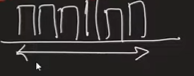

# ***`K Means Binning`***

- it is clustring Algo.
- **This technique is possible when the data is forming the clusture.**

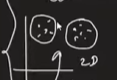

- as u see it forms the clusture of the data
- it is good that it work on nDimension data
  - Ex : 2D , 3D .. , 10D

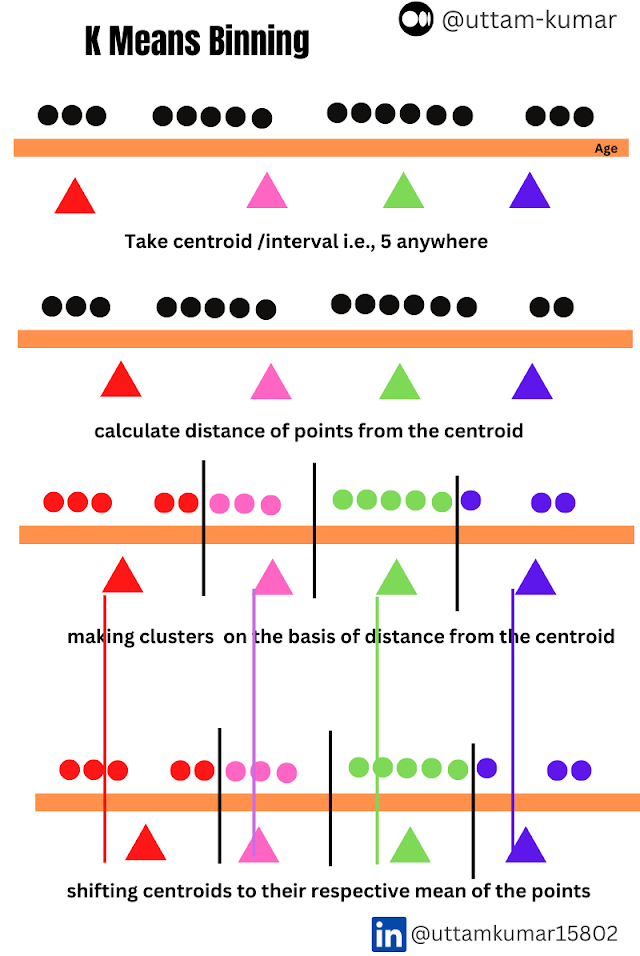

* The steps for K-Means Binning as illustrated in the diagram are:

* Take centroid/interval i.e., 5 anywhere:
* 1. Initially, select a specific number (e.g., 5 as shown in the diagram) of random centroids or intervals along the data range.
Calculate distance of points from the centroid:
* 2. For every data point, measure its distance to all the selected centroids.

* 3. Making clusters on the basis of distance from the centroid: Assign each data point to the cluster of its nearest centroid, forming initial groups.

* 4. Shifting centroids to their respective mean of the points: Recalculate the mean position of all points within each newly formed cluster and move the centroid to this new mean position.
* 5. This process of assignment and updating is typically repeated until the clusters stabilize.

# ***`Binerization`***

- it ios a special case of Discretization
  - It convert the continous values into the Binay data. [0,1]

In [ ]:
import pandas as pd

import numpy as np

In [5]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [6]:
df = pd.read_csv('/content/Titenic.csv',usecols=['Age','Fare','Survived'])

In [7]:
#we have droped the column having missing values
df.dropna(inplace=True)

In [8]:
df.shape

(714, 3)

In [9]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [10]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [11]:

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
X_train.head(2)

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542


In [13]:

clf = DecisionTreeClassifier()

In [14]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

In [15]:

accuracy_score(y_test,y_pred)

0.6363636363636364

In [16]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6288928012519561)

***`Now we are applying Discretization`***

In [17]:
kbin_age = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')
kbin_fare = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')

In [18]:
#kbin_age = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')
#kbin_fare = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')

In [19]:
trf = ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_fare,[1])
])

In [20]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

In [21]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42,  6.  , 16.  , 19.  , 21.  , 23.  , 25.  , 28.  , 30.  ,
              32.  , 35.  , 38.  , 42.  , 47.  , 54.  , 80.  ])             ],
      dtype=object)

In [22]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42,  6.  , 16.  , 19.  , 21.  , 23.  , 25.  , 28.  , 30.  ,
              32.  , 35.  , 38.  , 42.  , 47.  , 54.  , 80.  ])             ],
      dtype=object)

In [23]:
output = pd.DataFrame({
    'age':X_train['Age'],
    'age_trf':X_train_trf[:,0],
    'fare':X_train['Fare'],
    'fare_trf':X_train_trf[:,1]
})

In [24]:
output['age_labels'] = pd.cut(x=X_train['Age'],
                                    bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_labels'] = pd.cut(x=X_train['Fare'],
                                    bins=trf.named_transformers_['second'].bin_edges_[0].tolist())



In [25]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
753,23.0,5.0,7.8958,3.0,"(21.0, 23.0]","(7.775, 7.896]"
537,30.0,8.0,106.4250,13.0,"(28.0, 30.0]","(76.292, 108.9]"
10,4.0,0.0,16.7000,7.0,"(0.42, 6.0]","(14.454, 18.75]"
830,15.0,1.0,14.4542,7.0,"(6.0, 16.0]","(13.0, 14.454]"
243,22.0,4.0,7.1250,0.0,"(21.0, 23.0]","(0.0, 7.25]"


In [26]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)

In [27]:
accuracy_score(y_test,y_pred2)

0.6363636363636364

In [28]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6330790297339594)

In [29]:
def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)

    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ])

    X_trf = trf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy')))

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title("After")

    plt.show()

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Fare'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,1],color='red')
    plt.title("Fare")

    plt.show()


0.6330985915492958


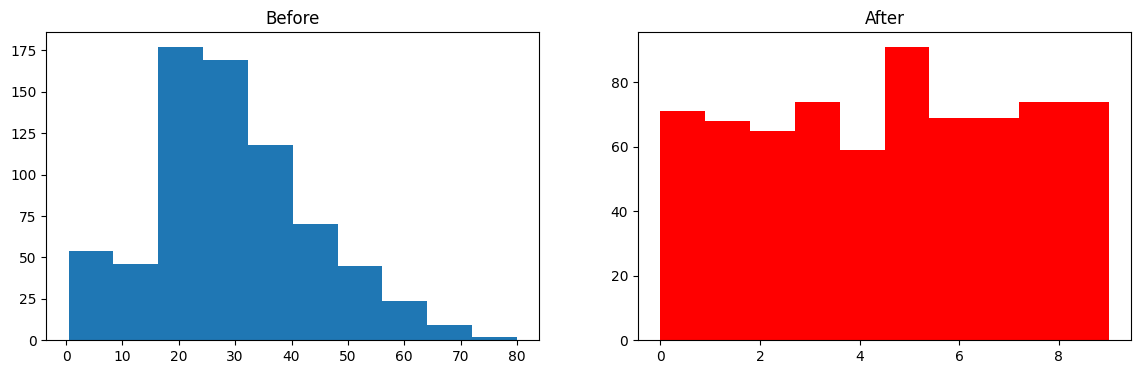

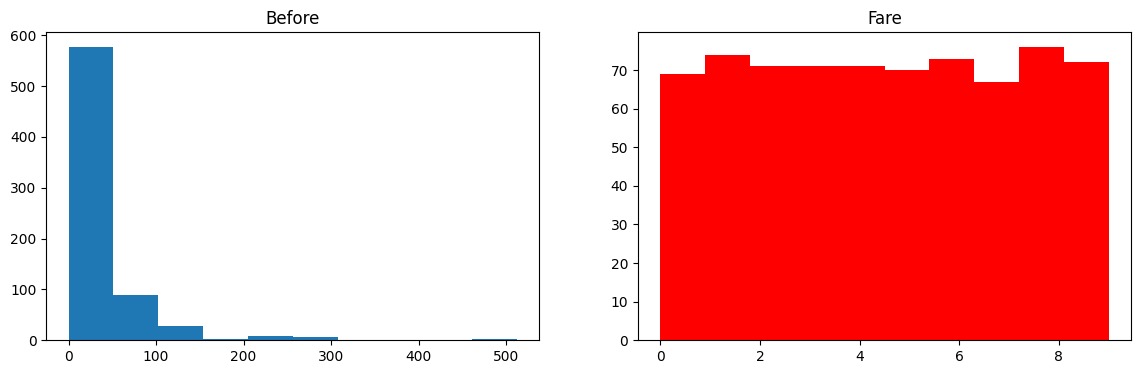

In [31]:
#discretize(5,'uniform')
# discretize(5,'kmeans')
discretize(10,'quantile')
